In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
from statsmodels.formula.api import ols

In [10]:
import pandas as pd

df = pd.read_csv("C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\Assignment Datasets\\booking.csv")

df_original = df.copy()

Target = 'booking_status'
df.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0,0
1,1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0,0
2,2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0,0
3,3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0,0
4,4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0,1


In [11]:
X = df_original.drop(Target, axis = 1)
y = df_original[Target]

df_original[Target].value_counts()

booking_status
0    25596
1    16504
Name: count, dtype: int64

In [12]:
# TODO: Examine the dataset for entries with zero adults and zero children

booking_counts = df[(df['no_of_adults'] == 0) & (df['no_of_children'] == 0)].shape[0] # Hint: Use 'no_of_adults' and 'no_of_children' column to extract this information
print("Number of bookings with zero adults and zero children:", booking_counts)

Number of bookings with zero adults and zero children: 16


booking_status     0     1
arrival_month             
1                747    58
2                884   317
3               1577   624
4               1924  1082
5               1955  1337
6               1945  1411
7               2463  2218
8               2722  3041
9               2981  2167
10              3530  2923
11              2029   774
12              2839   552


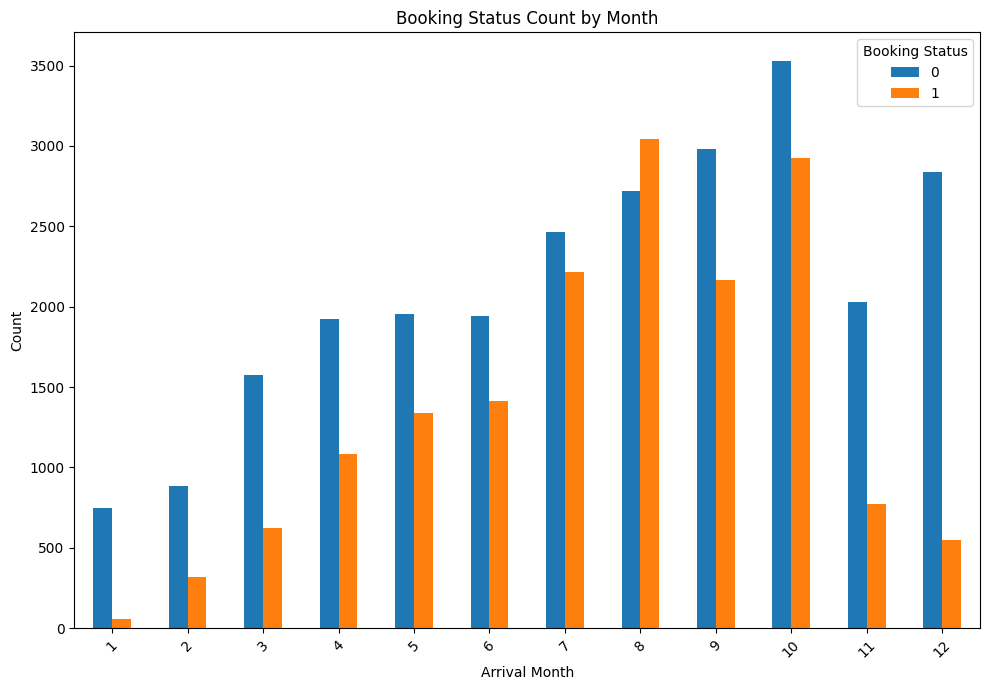

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Create a pivot table to count booking status for each month
booking_status_counts = df.pivot_table(index='arrival_month', columns='booking_status', aggfunc='size', fill_value=0) 
# Hint: Use 'arrival_month' and 'booking_status' columns and convert into pivot.

print(booking_status_counts)

# Plotting using the pivot table
booking_status_counts.plot(kind='bar', figsize=(10, 7)) # Hint: use bar plot
plt.title('Booking Status Count by Month')
plt.xlabel('Arrival Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Booking Status')
plt.tight_layout()  # Adjust layout to not cut off labels

plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def process_arrival_date(data):
    # Remove any pre-existing date columns that could conflict with the new transformations
    data.drop(columns=['year', 'month', 'day'], inplace=True, errors='ignore')

    # Renaming columns for uniformity
    temp = data.rename(columns={
        'arrival_year': 'year',
        'arrival_month': 'month',
        'arrival_date': 'day'
    })

    # TODO: Creating a datetime column from the year, month, and day columns
    data['date'] = pd.to_datetime(temp[['year', 'month', 'day']], errors='coerce')

    # TODO: Extract date features
    data['year'] = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['week'] = data['date'].dt.isocalendar().week.astype(float)
    data['day'] = data['date'].dt.day
    data['dayofweek'] = data['date'].dt.dayofweek
    data['quarter'] = data['date'].dt.quarter
    data['dayofyear'] = data['date'].dt.dayofyear

    # Cleanup: Remove 'date' column after extracting necessary features
    data.drop(columns='date', inplace=True)
    return data

# Test the function by applying it to a DataFrame 'df'
new_processed_df = process_arrival_date(df)

# Display missing values in the newly created columns to check for any NaN entries
missing_values = new_processed_df.isna().sum()
print(missing_values)

id                                       0
no_of_adults                             0
no_of_children                           0
no_of_weekend_nights                     0
no_of_week_nights                        0
type_of_meal_plan                        0
required_car_parking_space               0
room_type_reserved                       0
lead_time                                0
arrival_year                             0
arrival_month                            0
arrival_date                             0
market_segment_type                      0
repeated_guest                           0
no_of_previous_cancellations             0
no_of_previous_bookings_not_canceled     0
avg_price_per_room                       0
no_of_special_requests                   0
booking_status                           0
week                                    50
dayofweek                               50
quarter                                 50
dayofyear                               50
year       

In [16]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize weights
weights = np.ones(len(X)) / len(X)

# Train first weak learner
dt1 = DecisionTreeClassifier(random_state=10, max_depth=1)
dt1.fit(X, y)
y_pred_1 = dt1.predict(X)

# Update weights function
def update_weights(y, y_pred, weights):
    for i in range(len(weights)):
        if y[i] != y_pred[i]: # Hint: If actual value is not same as predicted value.
            weights[i] *= 1.5  # Increase the weight for misclassified instances
        else:
            weights[i] *= 0.5  # Decrease the weight for correctly classified instances
    return weights / np.sum(weights)  # Normalize the weights

# Apply first learner and update weights
weights = update_weights(y, y_pred_1, weights) # Hint: update weights using actual and predicted.

# Train second weak learner
dt2 = DecisionTreeClassifier(random_state=10, max_depth=1)
dt2.fit(X, y, sample_weight= weights)   # Utilize updated weights for learning for this sample_weight is used.
y_pred_2 = dt2.predict(X)

# Combine the weak learners' predictions
# Assuming a simple average for combination of both the predictions
final_prediction = np.round((y_pred_1 + y_pred_2) / 2.0).astype(int)

# Calculate the accuracy
final_accuracy = accuracy_score(y, final_prediction)
print(f"Final combined prediction accuracy: {final_accuracy}")

Final combined prediction accuracy: 0.7140380047505939


In [17]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

y_pred = np.full(shape=y.shape, fill_value=np.mean(y))

# Initialize pseudo residuals
pseudo_residuals = y - y_pred

learning_rate = 0.1

# Train first weak learner on pseudo residuals
dt1 = DecisionTreeRegressor(max_depth=1, random_state=10)
dt1.fit(X, pseudo_residuals)
y_pred_1 = dt1.predict(X)

# Update model predictions
y_pred += y_pred_1 * learning_rate # Hint: use learning rate.

# Calculate new pseudo residuals
pseudo_residuals = y - y_pred

# Train second weak learner on new pseudo residuals
dt2 = DecisionTreeRegressor(max_depth=1, random_state=10)
dt2.fit(X, pseudo_residuals)
y_pred_2 = dt2.predict(X)

# Update model predictions
y_pred += y_pred_2* learning_rate

# Calculate the accuracy using the mean squared error as a measure of accuracy for regression
final_accuracy = 1 - mean_squared_error(y, y_pred)
print(f"Final model accuracy: {final_accuracy}")

Final model accuracy: 0.7740567736555297


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble  import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# TODO: Split original data
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.2, random_state=10)

# TODO: Train Gradient Boosting Classifier on original data
gbc_orig = GradientBoostingClassifier(random_state=10)
gbc_orig.fit(X_train_orig, y_train_orig)
pred_orig = gbc_orig.predict(X_test_orig)
accuracy_orig = accuracy_score(y_test_orig, pred_orig)

# Using the Processed dataset from the previous process_arrival_date
new_df = new_processed_df.dropna()

# TODO: Split processed data (ensure to select the same target variable 'y')
X_train_proc, X_test_proc, y_train_proc, y_test_proc = train_test_split(new_processed_df.drop(Target, axis = 1), new_processed_df[Target], test_size=0.2, random_state=10)

# TODO: Train Random Forest on processed data
gbc_proc = GradientBoostingClassifier(random_state=10)
gbc_proc.fit(X_train_proc, y_train_proc)
pred_proc = gbc_proc.predict(y_test_proc)
accuracy_proc = accuracy_score(y_test_proc, pred_proc)

# Compare accuracies
print(f"Accuracy on original data: {accuracy_orig}")
print(f"Accuracy on processed data: {accuracy_proc}")

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [2]:
import pandas as pd

df = pd.read_csv("C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\Assignment Datasets\\booking.csv")

df_original = df.copy()

Target = 'booking_status'
df.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0,0
1,1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0,0
2,2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0,0
3,3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0,0
4,4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0,1


In [4]:
X = df_original.drop(Target, axis = 1)
y = df_original[Target]

df_original[Target].value_counts()

booking_status
0    25596
1    16504
Name: count, dtype: int64

The most important feature is: lead_time


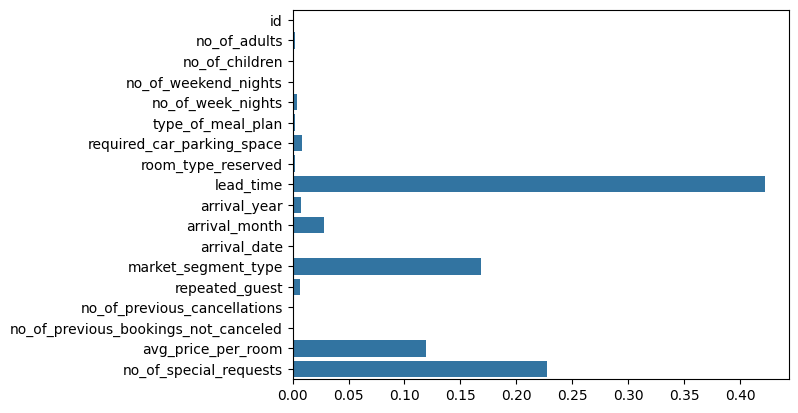

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# TODO: Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Initializing and training the Gradient Boosting Classifier
clf = GradientBoostingClassifier(random_state=10)
clf.fit(X_train, y_train)         # Hint: Fit the clasifier with training data

# TODO: Extracting feature importances
feature_importances = clf.feature_importances_

# Feature names
features = np.array(X.columns)

# TODO: Identifying the most important feature
most_important_feature = features[np.argmax(feature_importances)]

print(f"The most important feature is: {most_important_feature}")

sns.barplot(y= features, x=feature_importances)
plt.show()

In [7]:
from sklearn.metrics import accuracy_score
# Define the learning rates to test
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]
best_accuracy = 0
best_learning_rate = 0

# TODO: Train a model for each learning rate and evaluate its accuracy

for lr in learning_rates: # Hint: iterate over all learning rates
    model = GradientBoostingClassifier(learning_rate=lr, random_state=10)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test))
    print(lr, " : ", accuracy)

    if accuracy > best_accuracy:  # Hint: add the necessary condition
        best_accuracy = accuracy
        best_learning_rate = lr

print(f"The best learning rate is: {best_learning_rate} with an accuracy of: {best_accuracy}")

0.1  :  0.8042755344418052
0.05  :  0.8005938242280285
0.01  :  0.7859857482185273
0.005  :  0.7357482185273159
0.001  :  0.6086698337292161
The best learning rate is: 0.1 with an accuracy of: 0.8042755344418052


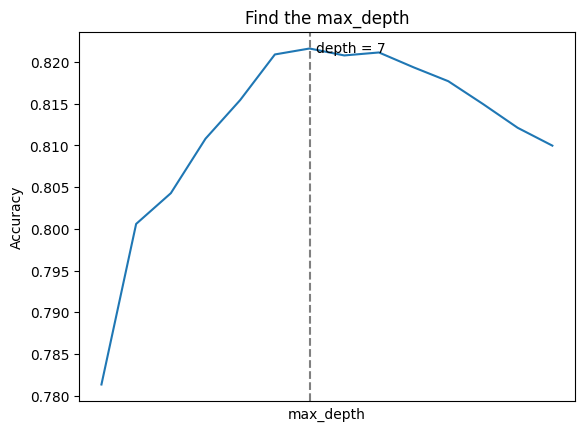

In [8]:
acc = []
best_depth = 0
best_acc = 0

# TODO: Train a model for each depth and evaluate its accuracy
for d in range(1,15):
    model = GradientBoostingClassifier(max_depth= d , random_state=10)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test))
    acc.append(accuracy)

    if accuracy > best_acc:   # Hint: add the necessary condition
      best_acc = accuracy
      best_depth = d


# Create the line plot
sns.lineplot(x=range(1, 15), y=acc)

# Remove x-ticks
plt.xticks([])

# Add x-axis label
plt.title("Find the max_depth")
plt.xlabel('max_depth')
plt.ylabel('Accuracy')

# Annotate the line at x = best_depth
highest_acc = acc[best_depth - 1]  # Adjusting for zero-based indexing
plt.axvline(x=best_depth, color='gray', linestyle='--')
plt.text(best_depth + 0.2, highest_acc, f"depth = {best_depth}", verticalalignment='center')

# Show the plot
plt.show()

In [9]:

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


In [15]:

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


# Assuming X_train and X_test are already defined
scaler = StandardScaler()

# TODO: Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# TODO: Transform the test data
X_test_scaled = scaler.transform(X_test)

# TODO: Train and test the GBC on the Scaled data
model_with_scaled = GradientBoostingClassifier(random_state=10)
model_with_scaled.fit(X_train_scaled, y_train)
accuracy_with_scaled = accuracy_score(y_test, model_with_scaled.predict(X_test_scaled))

# TODO: Train and test the GBC on the Original data (unscaled)
model_without_scaled = GradientBoostingClassifier(random_state=10)
model_without_scaled.fit(X_train, y_train)
accuracy_without_scaled = accuracy_score(y_test, model_without_scaled.predict(X_test))

print(f"accuracy_with_scaled = {accuracy_with_scaled}")
print(f"accuracy_without_scaled = {accuracy_without_scaled}")

print(f"Difference in accuracy = {accuracy_with_scaled - accuracy_without_scaled}") # TODO:

accuracy_with_scaled = 0.8042755344418052
accuracy_without_scaled = 0.8042755344418052
Difference in accuracy = 0.0


In [4]:
from sklearn.model_selection import GridSearchCV


# Defining the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8],
    'min_samples_split': [2, 4, 6]
}

# Initializing the Gradient Boosting Classifier
gbm = GradientBoostingClassifier(random_state=10)

# Setting up the grid search with cross-validation
grid_search = GridSearchCV(estimator=gbm, param_grid=param_grid, scoring="accuracy", cv=2, n_jobs=-1, verbose=1)

# Fitting the grid search to the data
grid_search.fit(X_train, y_train)

# Printing the best parameters and the corresponding score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

result = grid_search.cv_results_
for i in range(len(result["params"])):
  print(f"Parameters:{result['params'][i]} Mean_score: {result['mean_test_score'][i]} Rank: {result['rank_test_score'][i]}")

print(grid_search.best_estimator_)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
Best parameters: {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 300}
Best cross-validation score: 0.8179038004750594
Parameters:{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} Mean_score: 0.8136282660332541 Rank: 11
Parameters:{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} Mean_score: 0.8163598574821853 Rank: 6
Parameters:{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300} Mean_score: 0.8168349168646081 Rank: 5
Parameters:{'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 100} Mean_score: 0.8133907363420427 Rank: 12
Parameters:{'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 200} Mean_score: 0.8174287410926366 Rank: 3
Parameters:{'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300} Mean_score: 0.8175475059382422 Rank: 2
Parameters:{'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 100} Mean_score: 0.8144893111638956 Rank: 7
Parameters:{'max_depth': 5

In [5]:
# TODO: Sort the scores and parameters by rank
sorted_indices = np.argsort(result['rank_test_score'])
top_indices = sorted_indices[:5]  # Hint: Get top 5 indices

# TODO: Train a model for each of the top 5 parameter sets
for i in top_indices:
    params = result['params'][i]
    print(f"Training model number {i} with parameters: {params}")

    # TODO: Initialize and train the Gradient Boosting Classifier with the current set of parameters
    model = GradientBoostingClassifier(**params, random_state = 10)
    model.fit(X_train, y_train)

    # TODo: Evaluate the model on the test set
    score = model.score(X_test, y_test)
    print(f"Test score with parameters {params}: {score}\n")

Training model number 8 with parameters: {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 300}
Test score with parameters {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 300}: 0.8242280285035629

Training model number 5 with parameters: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300}
Test score with parameters {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300}: 0.8238717339667458

Training model number 4 with parameters: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 200}
Test score with parameters {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 200}: 0.8223277909738718

Training model number 7 with parameters: {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 200}
Test score with parameters {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 200}: 0.8207838479809976

Training model number 2 with parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Test score with parameters {'max_depth': 5, '

In [6]:
# TODO: Determine the 1th and 99th percentiles for 'lead_time'
low_threshold, high_threshold = np.percentile(X_train['lead_time'], [1,99])  # Hint: Use the numpy function to calculate percentiles. Remember to specify the percentile values as a list.

# Identify the indices of rows that are not considered outliers
#not_outliers = X_train['lead_time'].____(low_threshold, high_threshold)   # Hint: Use a comparison operation to generate a boolean mask where values are between the low and high thresholds.
not_outliers = (X_train['lead_time'] >= low_threshold) & (X_train['lead_time'] <= high_threshold)
# Count the number of outliers
num_outliers = np.sum(~not_outliers)

print(num_outliers)

334


In [9]:
# TODO: Train on the original dataset
original_clf = GradientBoostingClassifier(random_state=10)
original_clf.fit(X_train, y_train)
original_predictions = original_clf.predict(X_test)
original_accuracy = accuracy_score(y_test, original_predictions)
print(f"Original dataset accuracy: {original_accuracy}")

# TODO: Filter the training data to remove outliers
X_train_no_outliers = X_train[not_outliers]
y_train_no_outliers = y_train[not_outliers]

# Ensure there is data after removing outliers
if len(X_train_no_outliers) == 0:
    print("No data left after removing outliers based on 'lead_time'. Consider adjusting the percentile thresholds.")
else:
    # TODO: Train on the dataset without outliers
    clf_no_outliers = GradientBoostingClassifier(random_state=10)
    clf_no_outliers.fit(X_train_no_outliers, y_train_no_outliers)
    no_outliers_predictions = clf_no_outliers.predict(X_test)
    no_outliers_accuracy = accuracy_score(y_test, no_outliers_predictions)
    print(f"Dataset without outliers (based on 'lead_time') accuracy: {no_outliers_accuracy}")

    # TODO: Compare the performance
    if no_outliers_accuracy > original_accuracy:          # Hint: add the necessary condition
        print("Removing outliers based on 'lead_time' improved the model's accuracy.")
    else:
        print("Removing outliers based on 'lead_time' did not improve the model's accuracy.")

Original dataset accuracy: 0.8042755344418052
Dataset without outliers (based on 'lead_time') accuracy: 0.8065320665083135
Removing outliers based on 'lead_time' improved the model's accuracy.


In [10]:
# TODO: Train a Gradient Boosting Classifier using the default loss function (which is 'log_loss')
clf_log_loss = GradientBoostingClassifier(loss='log_loss', random_state=10)
clf_log_loss.fit(X_train, y_train)
predictions_log_loss = clf_log_loss.predict(X_test)
accuracy_log_loss = accuracy_score(y_test, predictions_log_loss)
print(f"Accuracy with the 'log_loss' loss function: {accuracy_log_loss}")

# TODO: Train a Gradient Boosting Classifier using the 'exponential' loss function
clf_exponential = GradientBoostingClassifier(loss='exponential', random_state=10)
clf_exponential.fit(X_train, y_train)
predictions_exponential = clf_exponential.predict(X_test)
accuracy_exponential = accuracy_score(y_test, predictions_exponential)
print(f"Accuracy with the 'exponential' loss function: {accuracy_exponential}")

# Compare the accuracies
if accuracy_exponential > accuracy_log_loss:
    print("The 'exponential' loss function model is more accurate on the test set.")
elif accuracy_exponential < accuracy_log_loss:
    print("The 'log_loss' loss function model is more accurate on the test set.")
else:
    print("Both models have the same accuracy on the test set.")

Accuracy with the 'log_loss' loss function: 0.8042755344418052
Accuracy with the 'exponential' loss function: 0.8057007125890736
The 'exponential' loss function model is more accurate on the test set.


Accuracy with 1 estimators: 0.6086698337292161
Accuracy with 5 estimators: 0.7355106888361045
Accuracy with 10 estimators: 0.7858669833729216
Accuracy with 20 estimators: 0.7891923990498813
Accuracy with 50 estimators: 0.8002375296912114
Accuracy with 100 estimators: 0.8042755344418052
Accuracy with 200 estimators: 0.8111638954869359
Accuracy with 300 estimators: 0.8157957244655581
Accuracy with 500 estimators: 0.8193586698337292
Accuracy with 1000 estimators: 0.8258907363420428


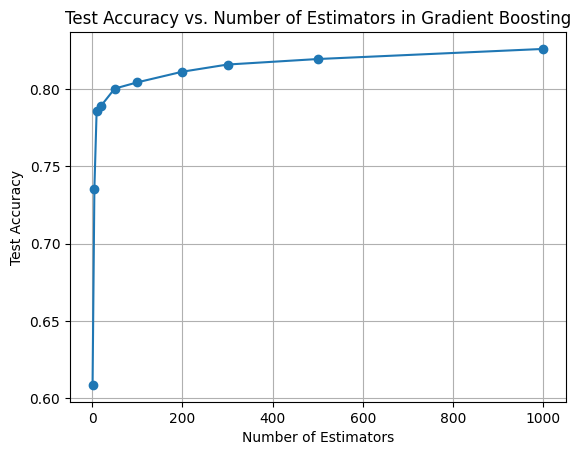

In [11]:
# Initialize the number of estimators
n_estimators_list = [1, 5, 10, 20, 50, 100, 200, 300, 500, 1000]
test_accuracies = []

# TODO: Train and evaluate the model with different numbers of weak learners
for n_estimators in n_estimators_list:
    clf = GradientBoostingClassifier(n_estimators=n_estimators, random_state=10)
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    test_accuracies.append(accuracy)
    print(f"Accuracy with {n_estimators} estimators: {accuracy}")

# Plotting the test accuracies
plt.plot(n_estimators_list, test_accuracies, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs. Number of Estimators in Gradient Boosting')
plt.grid(True)
plt.show()

In [11]:
import time
import pickle
from xgboost import XGBClassifier
import os

# TODO: Train XGBoost
start_time = time.time()
xgb_model = XGBClassifier(random_state=10)
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

# Save XGBoost model
with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

# TODO: Train GBC
start_time = time.time()
gbc_model = GradientBoostingClassifier(random_state=10)
gbc_model.fit(X_train, y_train)
gbc_train_time = time.time() - start_time

# Save GBC model
with open('gbc_model.pkl', 'wb') as file:
    pickle.dump(gbc_model, file)

# Output the training times
print(f"XGBoost training time: {xgb_train_time} seconds")
print(f"GBC training time: {gbc_train_time} seconds")

# Check the file sizes
xgb_file_size = os.path.getsize('xgb_model.pkl')
gbc_file_size = os.path.getsize('gbc_model.pkl')

# Output the file sizes
print(f"XGBoost model file size: {xgb_file_size} bytes")
print(f"GBC model file size: {gbc_file_size} bytes")

XGBoost training time: 0.19849109649658203 seconds
GBC training time: 6.557931423187256 seconds
XGBoost model file size: 377194 bytes
GBC model file size: 139258 bytes


XGBoost accuracy: 0.8243467933491686
Most important feature in XGBoost: market_segment_type
GBC accuracy: 0.8042755344418052
Most important feature in GBC: lead_time


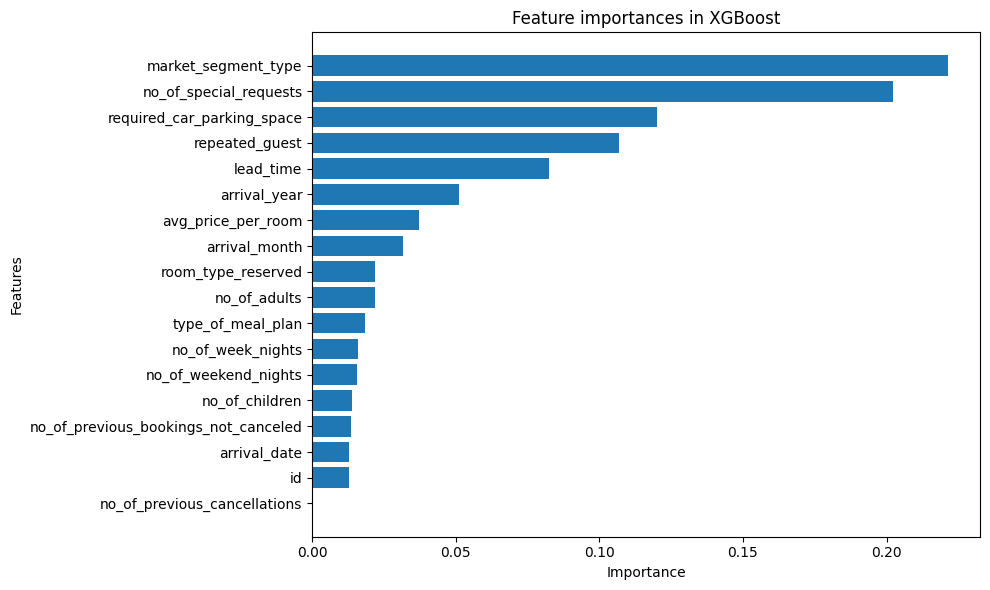

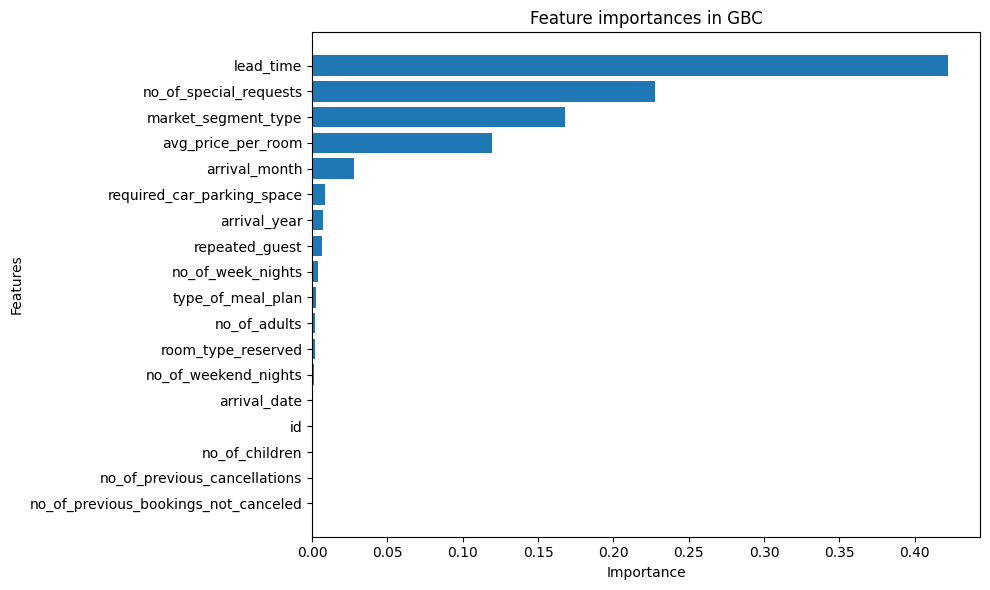

In [12]:
# TODD: Evaluate XGBoost on the test set
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost accuracy: {xgb_accuracy}")

# TODD: Determine the most important feature in XGBoost
xgb_feature_importances = xgb_model.feature_importances_
xgb_most_important_feature = features[np.argmax(xgb_feature_importances)]
print(f"Most important feature in XGBoost: {xgb_most_important_feature}")

# TODD: Evaluate GBC on the test set
gbc_predictions = gbc_model.predict(X_test)
gbc_accuracy = accuracy_score(y_test, gbc_predictions)
print(f"GBC accuracy: {gbc_accuracy}")

# TODD: Determine the most important feature in GBC
gbc_feature_importances = gbc_model.feature_importances_
gbc_most_important_feature =  features[np.argmax(gbc_feature_importances)]
print(f"Most important feature in GBC: {gbc_most_important_feature}")

# Feature importance for XGBoost
indices_xgb = np.argsort(xgb_feature_importances)

plt.figure(figsize=(10, 6))
plt.title("Feature importances in XGBoost")
plt.barh(range(X_train.shape[1]), xgb_feature_importances[indices_xgb], align="center")
plt.yticks(range(X_train.shape[1]), X.columns[indices_xgb])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Feature importance for GBC
indices_gbc = np.argsort(gbc_feature_importances)

plt.figure(figsize=(10, 6))
plt.title("Feature importances in GBC")
plt.barh(range(X_train.shape[1]), gbc_feature_importances[indices_gbc], align="center")
plt.yticks(range(X_train.shape[1]), X.columns[indices_gbc])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [14]:
from lightgbm import LGBMClassifier

# Train XGBoost
start_time = time.time()
xgb_model = XGBClassifier(random_state=10)
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

# Train LightGBM
start_time = time.time()
lgb_model = LGBMClassifier(random_state=10)
lgb_model.fit(X_train, y_train)
lgb_train_time = time.time() - start_time
lgb_predictions = lgb_model.predict(X_test)
lgb_accuracy = accuracy_score(y_test, lgb_predictions)

# Output the results
print(f"XGBoost training time: {xgb_train_time} seconds")
print(f"XGBoost test accuracy: {xgb_accuracy}")
print(f"LightGBM training time: {lgb_train_time} seconds")
print(f"LightGBM test accuracy: {lgb_accuracy}")

[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 33680, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392191 -> initscore=-0.438111
[LightGBM] [Info] Start training from score -0.438111
XGBoost training time: 0.16742300987243652 seconds
XGBoost test accuracy: 0.8243467933491686
LightGBM training time: 3.081160545349121 seconds
LightGBM test accuracy: 0.8184085510688837


In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from mlxtend.classifier import StackingClassifier
from sklearn.metrics import accuracy_score


# Initialize the base learners
rf = RandomForestClassifier(random_state=10)
gbc = GradientBoostingClassifier(random_state=10)
xgb = XGBClassifier(random_state=10)
lgbm = LGBMClassifier(random_state=10)
ada = AdaBoostClassifier(random_state=10)

# Initialize the Stacking Classifier using XGBoost as meta-learner
stacking_clf = StackingClassifier(classifiers=[rf, gbc, lgbm, ada],
                                  meta_classifier=xgb,
                                  use_probas=True,
                                  average_probas=False)

# Train the stacking classifier
stacking_clf.fit(X_train, y_train)

# Evaluate the stacking model
stacking_predictions = stacking_clf.predict(X_test)
stacking_accuracy = accuracy_score(y_test, stacking_predictions)
print("---"*10)
print(f"Stacking Model Accuracy: {stacking_accuracy}")
print("---"*10)

# Initialize the Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('rf', rf), ('gbc', gbc), ('xgb', xgb), ('lgbm', lgbm), ('ada', ada)
])

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Evaluate the voting model
voting_predictions = voting_clf.predict(X_test)
voting_accuracy = accuracy_score(y_test, voting_predictions)
print("---"*10)
print(f"Voting Model Accuracy: {voting_accuracy}")

# Compare the accuracies
print("---"*10)
if stacking_accuracy > voting_accuracy:
    print("Stacking ensemble is more accurate.")
elif stacking_accuracy < voting_accuracy:
    print("Voting ensemble is more accurate.")
else:
    print("Both ensembles have the same accuracy.")
print("---"*10)

[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 33680, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392191 -> initscore=-0.438111
[LightGBM] [Info] Start training from score -0.438111
------------------------------
Stacking Model Accuracy: 0.8149643705463183
------------------------------
[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightG

In [18]:
# TODO: Layer 1: Train a LightGBM classifier
lgb_clf = LGBMClassifier(random_state=10)
lgb_clf.fit(X_train, y_train)

# TODO: Get the prediction probabilities for the training set and testing set
lgb_train_prob = lgb_clf.predict_proba(X_train)[:, 1]   # Hint: we want probabilities not the predictions
lgb_test_prob = lgb_clf.predict_proba(X_test)[:, 1]

# Filter out instances with confidence above 75% and below 25%
filter_threshold = 0.75

# TODO: Filter the DataFrame based on the LightGBM model's prediction probabilities above 75% and below 25%
filtered_train_df = X_train[(lgb_train_prob < filter_threshold) | (lgb_train_prob > (1 - filter_threshold))]
filtered_y_train = y_train[(lgb_train_prob < filter_threshold) | (lgb_train_prob > (1 - filter_threshold))]

# TODO: Layer 2: Train a XGBoost classifier on the filtered training set
xgb_clf = XGBClassifier(random_state=10)
xgb_clf.fit(filtered_train_df, filtered_y_train)

# TODO: Make final predictions on the  test set with the XGBoost model
final_predictions = xgb_clf.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)
print(f"Final Model Accuracy on Filtered Test Set: {final_accuracy}")

[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 33680, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392191 -> initscore=-0.438111
[LightGBM] [Info] Start training from score -0.438111
Final Model Accuracy on Filtered Test Set: 0.8243467933491686


In [5]:
import pandas as pd

df = pd.read_csv("C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\Assignment Datasets\\health_outcome_dataset.csv")
df.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [6]:
import pandas as pd
from sklearn.impute import SimpleImputer

df.drop('lesion_3', inplace = True, axis = 1)

# Create imputer objects
num_imputer = SimpleImputer(strategy='median')  # Imputer for numerical data
cat_imputer = SimpleImputer(strategy='most_frequent')  # Imputer for categorical data

# Define columns by type
num_cols = ['rectal_temp', 'pulse', 'respiratory_rate']  # Numerical columns
cat_cols = ['temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time',
            'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube',
            'nasogastric_reflux', 'abdomen', 'abdomo_appearance', 'rectal_exam_feces']  # Categorical columns

# Apply imputation
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [7]:
df['outcome'].value_counts()

outcome
lived         574
died          410
euthanized    251
Name: count, dtype: int64

outcome
died          90.207317
euthanized    86.573705
lived         68.918118
Name: pulse, dtype: float64


C:\Users\njain121\AppData\Local\Temp\ipykernel_30884\1892736920.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome', y='pulse', data=df, palette=custom_palette)
C:\Users\njain121\AppData\Local\Temp\ipykernel_30884\1892736920.py:12: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(x='outcome', y='pulse', data=df, palette=custom_palette)


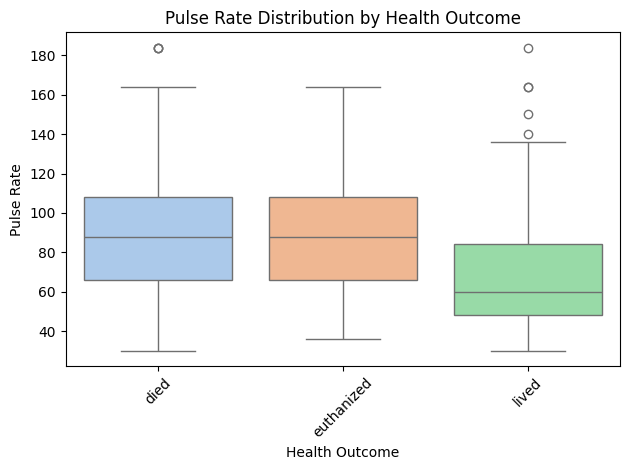

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Group the dataframe by 'outcome' and calculate the average 'pulse' for each outcome category.
pulse_outcome_data = df.groupby('outcome')['pulse'].mean()  # Consider what function might summarize the data effectively.
print(pulse_outcome_data)

# Set a custom color palette (optional)
custom_palette = sns.color_palette("pastel")

# TODO: Utilize seaborn to create a box plot that shows variation within grouped data.
sns.boxplot(x='outcome', y='pulse', data=df, palette=custom_palette)
plt.title('Pulse Rate Distribution by Health Outcome')
plt.xlabel('Health Outcome')
plt.ylabel('Pulse Rate')
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to not cut off labels

plt.show()

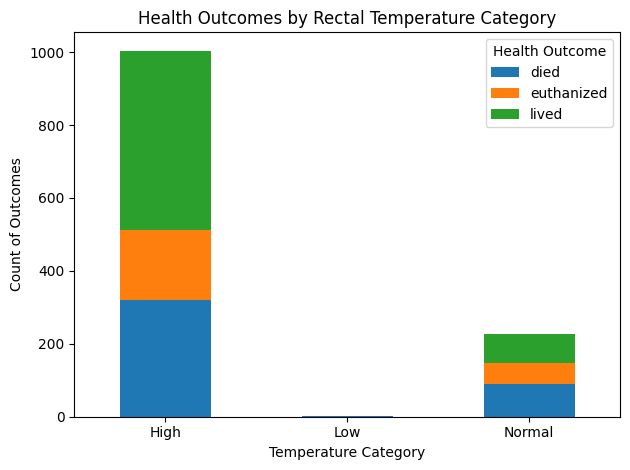

In [26]:
# Define function to categorize rectal temperature
def categorize_temp(temp):
    # TODO: Return the category based on temperature values (use if-elif-else structure).
    
    if temp < 36.0:
        return 'Low'
    elif 36.0 <= temp <= 37.5:
        return 'Normal'
    else:
        return 'High'


# Apply function to create a new column
df['temp_category'] = df['rectal_temp'].apply(categorize_temp)  # TODO: Choose the appropriate DataFrame method to apply a function.

# Grouping data by temperature category and outcome for plotting
grouped_data = df.groupby(['temp_category', 'outcome']).count()['id'].reset_index()  # TODO: Group by two columns and count a unique identifier.
grouped_data.columns = ['Temperature Category', 'Outcome', 'Count']

# Create a pivot table for visualization
pivot_table = pd.pivot_table(grouped_data, values= 'Count' , index='Temperature Category', columns='Outcome', fill_value=0)  # TODO: Fill the blanks to correctly set up the pivot table parameters.

# Plotting the data
pivot_table.plot(kind='bar', stacked=True)
plt.title('Health Outcomes by Rectal Temperature Category')
plt.xlabel('Temperature Category')
plt.ylabel('Count of Outcomes')
plt.xticks(rotation=0)
plt.legend(title='Health Outcome')
plt.tight_layout()  # Adjust layout to not cut off labels

plt.show()

In [16]:
from scipy.stats import chi2_contingency  # TODO: Import the necessary function for performing the Chi-square test.

threshold = .05

print(f'{"Column":<25} | Test result')
print('----------------------------------------')

for column in cat_cols:
    # Create a contingency table
    contingency_table = pd.crosstab(df[column], df['outcome'])  # TODO: Create a contingency table from two categorical columns.

    # Perform the Chi-Square test
    chi2, p, dof, expected_freq = chi2_contingency(contingency_table)  # TODO: Apply the imported function to compute the Chi-square statistic and p-value.

    print(f'{column:<25} |   ', '\033[32mPassed' if p < threshold else '\033[31mFailed', '\033[0m')

Column                    | Test result
----------------------------------------
temp_of_extremities       |    Passed 
peripheral_pulse          |    Passed 
mucous_membrane           |    Passed 
capillary_refill_time     |    Passed 
pain                      |    Passed 
peristalsis               |    Passed 
abdominal_distention      |    Passed 
nasogastric_tube          |    Passed 
nasogastric_reflux        |    Passed 
abdomen                   |    Passed 
abdomo_appearance         |    Passed 
rectal_exam_feces         |    Passed 


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, OrdinalEncoder  # TODO: Import necessary preprocessing classes.
from sklearn.compose import ColumnTransformer

# Drop unnecessary columns
df_temp = df.drop(['id'], axis=1)

# Identify numerical and categorical columns
numerical_cols = df_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()  # TODO: Specify data types to select numerical (int and float both) columns.
categorical_cols = df_temp.select_dtypes(include=['object']).columns.tolist()  # TODO: Specify the data type for categorical(object).

# Remove the target column from the feature lists
categorical_cols.remove('outcome')

# Prepare target and features
X = df_temp.drop('outcome', axis=1)
y = df_temp['outcome']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)  # TODO: Use the appropriate function to split the data.

# Create transformers for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # TODO: Choose the correct transformer for numerical data.
        ('cat', OrdinalEncoder(), categorical_cols)  # TODO: Choose the correct transformer for categorical data that handles unknown categories.
    ])

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)  # TODO: Fit and Apply the preprocessor to training data.
X_test = preprocessor.transform(X_test)  # TODO: Apply the preprocessor to test data.


print(f'{"Column":<25} | Number of unique values')
print('------'*10)
for i in categorical_cols:
    print(f'{i:<25} |   ', f'\033[32m{df[i].unique()}' , '\033[0m')


Column                    | Number of unique values
------------------------------------------------------------
surgery                   |    ['yes' 'no'] 
age                       |    ['adult' 'young'] 
temp_of_extremities       |    ['cool' 'cold' 'normal' 'warm'] 
peripheral_pulse          |    ['reduced' 'normal' 'absent' 'increased'] 
mucous_membrane           |    ['dark_cyanotic' 'pale_cyanotic' 'pale_pink' 'normal_pink' 'bright_pink'
 'bright_red'] 
capillary_refill_time     |    ['more_3_sec' 'less_3_sec' '3'] 
pain                      |    ['depressed' 'mild_pain' 'extreme_pain' 'alert' 'severe_pain' 'slight'] 
peristalsis               |    ['absent' 'hypomotile' 'normal' 'hypermotile' 'distend_small'] 
abdominal_distention      |    ['slight' 'moderate' 'none' 'severe'] 
nasogastric_tube          |    ['slight' 'none' 'significant'] 
nasogastric_reflux        |    ['less_1_liter' 'more_1_liter' 'none' 'slight'] 
rectal_exam_feces         |    ['decreased' 'absent' 'nor

Bernoulli Naive Bayes Classification Report:
              precision    recall  f1-score   support

        Died       0.67      0.80      0.73        89
  Euthanized       0.56      0.67      0.61        42
       Lived       0.75      0.59      0.66       116

    accuracy                           0.68       247
   macro avg       0.66      0.68      0.66       247
weighted avg       0.69      0.68      0.67       247



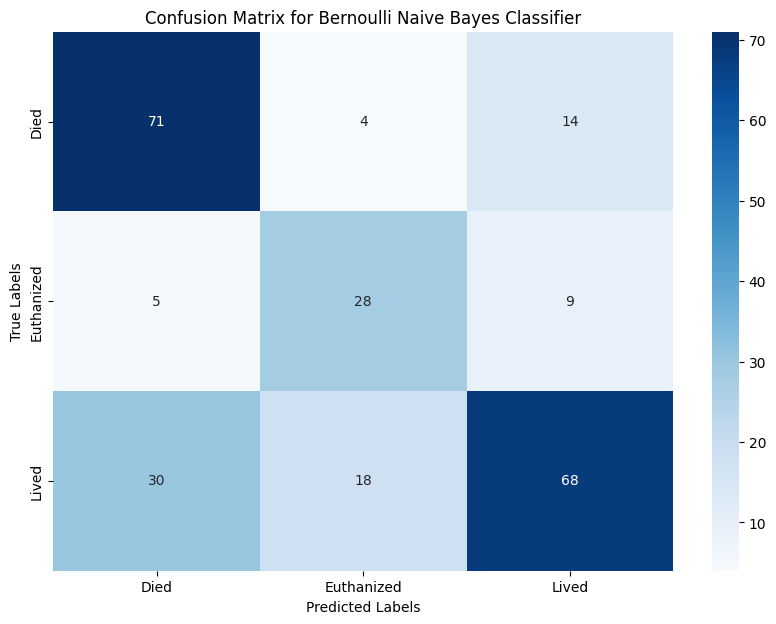

In [29]:
from sklearn.naive_bayes import BernoulliNB  # TODO: Correctly import the Bernoulli Naive Bayes classifier.
from sklearn.metrics import classification_report, confusion_matrix

# Encoding the 'outcome' variable
outcome_map = {'died': 0, 'euthanized': 1, 'lived': 2}
y_train_encoded = y_train.map(outcome_map)  # TODO: Apply the mapping to the 'y_train' series.
y_test_encoded = y_test.map(outcome_map)  # TODO: Apply the mapping to the 'y_test' series.

# Train Bernoulli Naive Bayes classifier
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(X_train, y_train_encoded)  # TODO: Fit the Bernoulli Naive Bayes model using training data.
y_pred_ber = bernoulli_nb.predict(X_test)  # TODO: Predict outcomes using the test set.

print("Bernoulli Naive Bayes Classification Report:")
print(classification_report(y_test_encoded, y_pred_ber, target_names=['Died', 'Euthanized', 'Lived']))  # TODO: Fill in the classification report with the appropriate arguments.

# Generate the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_ber) # TODO: Provide the correct variables to generate the confusion matrix.
categories = ['Died', 'Euthanized', 'Lived']

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Bernoulli Naive Bayes Classifier')
plt.show()

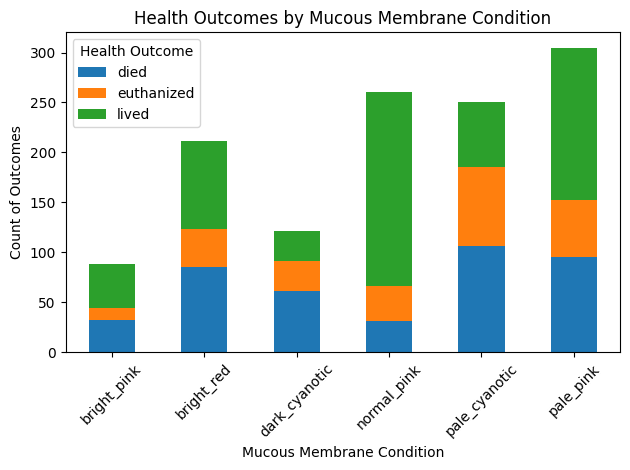

In [13]:
# Grouping data by mucous membrane condition and outcome for plotting
grouped_data = df.groupby(['mucous_membrane', 'outcome']).count()['id'].reset_index()  # TODO: Choose appropriate columns for grouping and a method to summarize the data.
grouped_data.columns = ['Mucous Membrane Condition', 'Outcome', 'Count']

# Create a pivot table for visualization
pivot_table = pd.pivot_table(grouped_data, values='Count', index='Mucous Membrane Condition', columns='Outcome', fill_value=0)  # TODO: Determine which values will be summarized and how they should be arranged in the pivot table.

# Plotting the data
pivot_table.plot(kind='bar', stacked=True)
plt.title('Health Outcomes by Mucous Membrane Condition')
plt.xlabel('Mucous Membrane Condition')
plt.ylabel('Count of Outcomes')
plt.xticks(rotation=45)
plt.legend(title='Health Outcome')
plt.tight_layout()  # Adjust layout to not cut off labels

plt.show()


In [20]:
from sklearn.naive_bayes import GaussianNB  # TODO: Import the Gaussian Naive Bayes classifier.
from sklearn.metrics import classification_report, confusion_matrix  # TODO: Import necessary functions for evaluation.

# Encoding the 'outcome' variable
outcome_map = {'died': 0, 'euthanized': 1, 'lived': 2}
y_train_encoded = y_train.map(outcome_map)  # TODO: Apply the mapping to the 'y_train' series.
y_test_encoded = y_test.map(outcome_map)  # TODO: Apply the mapping to the 'y_test' series.

# Initialize and train Gaussian Naive Bayes classifier
model = GaussianNB()
model.fit(X_train, y_train_encoded)  # TODO: Fit the model using the training data.

# Predict on the test set
y_pred = model.predict(X_test)  # TODO: Make predictions using the test data.

# Generate the classification report
report = classification_report(y_test_encoded, y_pred, target_names=['Died', 'Euthanized', 'Lived'])  # TODO: Provide the correct variables to generate the classification report.
print(report)

              precision    recall  f1-score   support

        Died       0.49      0.98      0.65        89
  Euthanized       0.56      0.57      0.56        42
       Lived       0.88      0.20      0.32       116

    accuracy                           0.54       247
   macro avg       0.64      0.58      0.51       247
weighted avg       0.69      0.54      0.48       247



In [21]:
from sklearn.model_selection import cross_val_score  # TODO: Import the function to perform cross-validation.

# Perform 5-fold cross-validation using 'f1_weighted' as the scoring metric
# Review the scoring parameters available in the documentation to ensure correct usage. https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
cv_scores = cross_val_score(GaussianNB(), X_train, y_train_encoded, cv=5, scoring='f1_weighted')  # TODO: Initialize the classifier, set the number of folds, and specify the scoring metric.

# Calculate the average of the cross-validation scores
average_cv_score = cv_scores.mean()  # TODO: Determine the appropriate method to calculate the mean of the scores.
print(f"Average F1 weighted score across 5 folds: {average_cv_score:.2f}")

Average F1 weighted score across 5 folds: 0.50


In [22]:

from sklearn.naive_bayes import MultinomialNB  # Import the Multinomial Naive Bayes classifier
from sklearn.preprocessing import MinMaxScaler  # Import MinMaxScaler for data normalization

# Initialize MinMaxScaler
scaler = MinMaxScaler()  # TODO: Instantiate the scaler.

# Scale X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)  # TODO: Fir and Apply the scaler to train data.
X_test_scaled = scaler.transform(X_test)  # TODO: Apply the scaler to test data.

# Train Multinomial Naive Bayes classifier
multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_train_scaled, y_train)  # TODO: Fit the Multinomial Naive Bayes model to the scaled training data.
y_pred_multinomial = multinomial_nb.predict(X_test_scaled)  # TODO: Predict the test set results with the trained model.

print("Multinomial Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_multinomial, target_names=['Died', 'Euthanized', 'Lived']))  # TODO: Provide the correct arguments to generate the classification report.


Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

        Died       0.69      0.54      0.60        89
  Euthanized       0.62      0.57      0.59        42
       Lived       0.62      0.73      0.67       116

    accuracy                           0.64       247
   macro avg       0.64      0.61      0.62       247
weighted avg       0.64      0.64      0.63       247



In [23]:
from sklearn.model_selection import GridSearchCV  # TODO: Import the necessary class for optimizing hyperparameters.
import numpy as np

# Define a range of alpha values to test
alpha_range = np.linspace(0.0, 1.0, 11)

# Setup GridSearchCV to find the best alpha
param_grid = {'var_smoothing': alpha_range}  # TODO: Specify the parameter name for Laplace smoothing in GaussianNB.
gnb = GaussianNB()
clf = GridSearchCV(gnb, param_grid, cv=5, scoring='f1_weighted')  # TODO: Fill in the GridSearchCV constructor with the correct model and parameters.
clf.fit(X_train, y_train)  # TODO: Fit the GridSearchCV to the training data.

# Best alpha and its score
best_alpha = clf.best_params_['var_smoothing']  # TODO: Extract the best alpha value from clf.
best_score = clf.best_score_  # TODO: Extract the best score from clf.
print(f"Best alpha: {best_alpha}")
print(f"Best scoring f1_weighted: {best_score:.2f}")

Best alpha: 0.9
Best scoring f1_weighted: 0.65


Feature Importance based on absolute means of class conditional distributions:
nasogastric_reflux       3.093584
nasogastric_tube         2.627840
rectal_exam_feces        2.094395
abdomen                  1.809921
total_protein            1.424576
lesion_1                 1.359208
nasogastric_reflux_ph    1.353643
abdominal_distention     1.192330
packed_cell_volume       1.148624
abdomo_appearance        1.042088
surgical_lesion          0.939177
abdomo_protein           0.811958
lesion_2                 0.756599
pain                     0.716326
cp_data                  0.496992
temp_of_extremities      0.440712
hospital_number          0.333712
pulse                    0.332115
respiratory_rate         0.291780
peripheral_pulse         0.215117
surgery                  0.153676
rectal_temp              0.151303
peristalsis              0.055472
capillary_refill_time    0.047601
mucous_membrane          0.030234
age                      0.028012
Name: Mean Importance, dtype: float64

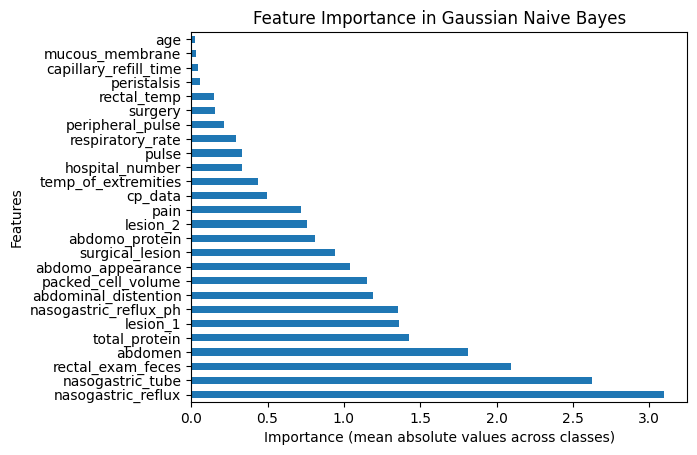

In [24]:
# Train the Gaussian Naive Bayes model
model = GaussianNB(var_smoothing = 0.3) # TODO: Set the smoothing parameter to 0.3.
model.fit(X_train, y_train)

# TODO: Use the appropriate numpy function to calculate the absolute values of the means
feature_importances = np.abs(model.theta_)   # TODO: Access the attribute that stores the class conditional means.

# Create a DataFrame to view these importances
importance_df = pd.DataFrame(feature_importances, columns=X.columns)

# Summing the importances across classes to get an overall importance score for each feature
importance_df.loc['Mean Importance'] = importance_df.mean(axis=0)  # TODO: Aggregate the means to get a single importance score per feature
sorted_importance = importance_df.loc['Mean Importance'].sort_values(ascending=False)   # TODO: Sort the features based on importance

print("Feature Importance based on absolute means of class conditional distributions:")
print(sorted_importance)

# Optionally, visualize these importances
import matplotlib.pyplot as plt
sorted_importance.plot(kind='barh')
plt.title('Feature Importance in Gaussian Naive Bayes')
plt.ylabel('Features')
plt.xlabel('Importance (mean absolute values across classes)')
plt.show()